# ⚖️📈 **Par Yields and the Term Structure**
<br>

<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Four-Chapter-Two/blob/master/colab/Colab_Calculating_Par_Yields.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Four-Chapter-Two/master?urlpath=lab/tree/notebooks/Calculating_Par_Yields.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>
  
  <a href="https://patrickjhess.github.io/Volume-Four-Chapter-Two/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>
  
Par Yields are directly calculated from the term structure of interest rates. At any point in time, Par Yields are the estimated coupon cost of issuing "default-free" debt with a par value of \$100. They are another example of how the term structure of interest rates informs financial decisions—issuers calibrate costs, investors estimate returns, lenders measure interest rates, and borrowers evaluate terms. It all begins with the term structure of interest rates.

In this notebook, Nelson and Siegel estimates of the term structure are used to calculate par yields. Nelson-Siegel is a parsimonious model of the term structure that relies on four parameters:
<br>

$$r(t) = \beta_0 + \beta_1 \left( \frac{1 - e^{-t/\tau}}{t/\tau} \right) + \beta_2 \left( \frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau} \right)$$

* $\beta_0$ (**Level**):The long-term rate.
* $\beta_1$ (**Slope**): The short-term component.
* $\beta_2$ (**Curvature/Shape**): The medium-term hump.
* $\tau$ (**Scaling**): The decay factor that dictates where the curvature peaks.

Chapter Four of the *Term Structure Of Interest Rates* estimated the Nelson-Siegel model with FEDInvest data. In this notebook, we estimate the model again and use it to calculate and compare par yields to those reported in the FRED database.

**Anchoring to SOFR**

In the Nelson-Siegel model, the short rate of interest as $t \to 0$ equals:

$$r(0) = \beta_0 + \beta_1$$

The FRED database includes the Secured Overnight Financing Rate (SOFR)—the rate charged on overnight lending that is overcollateralized with U.S. Treasury securities. SOFR is considered the best estimate of the instantaneous spot rate of interest. We explicitly incorporate SOFR in our Nelson-Siegel estimates using two distinct approaches:


* Unrestricted Estimates: SOFR is used to improve the initial guess of $\beta_1$, calculated as the difference between SOFR and our initial guess of $\beta_0$. The optimization is then allowed to run freely.
* Restricted Estimates: We take a strong stance and force the value of $\beta_1$ to be strictly equal to the difference between SOFR and the estimate of $\beta_0$ throughout the optimization.

Par yields are calculated and compared using both the unrestricted and restricted Nelson-Siegel estimates.



:::{important} [ ▼ ] How to use this page: Run, Copy, & Download
:class: dropdown

<ul>
  <li><b>⏻ Run code right here:</b> Click the <b>Power Button</b> icon at the top of the screen to activate <b>Live Code</b>.</li>
  <li><b>📋 Copy code:</b> Hover over any code block and click the <b>Clipboard icon</b> in the top-right corner.</li>
  <li><b>📥 Download this file:</b> Click the <b>Download icon</b> (downward arrow) at the top right of the screen to save this exact notebook to your computer.</li>
</ul>
:::

<details>
<summary><b>🤔 Notebook Setup: Why the "Try/Except" Imports?</b></summary>

**The Goal:**
To ensure this notebook runs perfectly whether you are using **Google Colab**, a local **Jupyter instance**, or a remote server without you having to manually install software.

**Key Concepts in this Section:**
*   **Standard Libraries:** Modules like `os`, `sys`, and `datetime` come "in the box" with Python. We use them for system tasks and date math.
*   **External Libraries:** NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.
*   **The `try/except` Logic:** This is a safety net.
    1. We **try** to import the library.
    2. If it fails (because it's not installed), the **except** block triggers a `%pip install` to download it automatically.
*   **Aliasing (`as np`):** We rename `numpy` to `np` to save keystrokes. In professional finance code, `np` and `pd` are the universal shorthand.

</details>

## 🛠️ Preparing the Notebook
<details>
<summary><b>👉 Click to Expand: 📦 Importing Libraries, Modules, and Functions</b></summary>


As a best practice, we always begin by importing our necessary dependencies in the very first code cell. Here we import the `datetime` module, the `pandas, numpy,` and `scipy` libraries ✨

```
from datetime import datetime, date


try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd

try:
    from scipy.optimize import minimize
except:
    !pip -q install scipy
    from scipy.optimize import minimize
```
SciPy stands for scientific Python and is a powerful library built around NumPy,  In this notebok, the function `minimze` of `scipy.optimize` (a subset of SciPy) is used to find the estimates of $\beta_0,\beta_1,\ \beta_2,\text{ and }\tau$.  

**👀 Keep an eye out**: As we progress, pay attention to how the `financial_quant` package is imported as `fq`, and how every reference to its functions begins with fq.. 💡 This follows the exact same standard practice we demonstrated in Chapter One with NumPy (np) and Pandas (pd).

</details>

In [1]:

from datetime import datetime, date


try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd

try:
    from scipy.optimize import minimize
except:
    !pip -q install scipy
    from scipy.optimize import minimize

## 📦 Getting Functions from financial_quant package

<details>
<summary><b style="font-size:1.2em; color: #1976d2; cursor: pointer;">🔌 Professional Packaging: How GitHub Installations Work</b></summary>
<br>
<p><b>The Logic:</b><br>
Usually, Python looks for modules as <code>.py</code> files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.</p>

<p><b>The Workflow:</b></p>
<ol>
<li><b>Fetch & Build:</b> The <code>%pip install git+https://...</code> command tells your Jupyter environment to clone the repository from GitHub and install the <code>financial_quant</code> package directly into your system's site-packages directory.</li>
<li><b>Import:</b> <code>import financial_quant as fq</code> loads the package into your notebook's memory and assigns it the quick alias <code>fq</code>.</li>
<li><b>Routing:</b> Behind the scenes, a special file called <code>__init__.py</code> acts as the package's "front door." It automatically gathers complex tools from deeply nested folders (like our fixed-income models and chart visualizers) and serves them up directly to the surface.</li>
<li><b>Execute:</b> You don't have to worry about where the files live. You just type <code>fq.one_y_axis() or fq.calc_ytm()</code>, and Python immediately knows where to route the request.</li>
</ol>

<p><b>Why do this?</b><br>
This is exactly how professional software engineering teams manage and distribute code. It keeps your notebooks incredibly clean, ensures everyone is using the exact same version of the math models, and guarantees your code is 100% portable to any cloud environment</p>
</details>

In [2]:
%pip install -q git+https://github.com/PatrickJHess/quant_repo.git 
import financial_quant as fq

Note: you may need to restart the kernel to use updated packages.


:::{important} ☁️ Cloud-Loading: How In-Memory Modules Work
:class: dropdown

**The Logic:**
Usually, Python looks for modules as `.py` files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.

**The Workflow:**
1. **Fetch:** `requests.get(url)` grabs the raw text of your Python script from Dropbox.
2. **Instantiate:** `ModuleType(module_name)` creates an empty "container" in your computer's RAM.
3. **Execute:** `exec(code, module.__dict__)` runs that text inside the container, turning text into live functions.
4. **Register:** By adding it to `sys.modules`, we tell Python: *"If I try to import this later, don't look on the disk—look right here in the memory."*

**Why do this?**
It makes your notebooks **100% portable**. A user can open this in a brand-new environment, and as long as they have an internet connection, all your custom financial functions will "just work."
:::

## ✅ Authenicate your FRED API key
Data is being accessed from the FRED database. The function `secure_key_setup` makes your FRED API key available in the notebook.  If you haven't yet added your key, the function will direct you to do so.

In [3]:
fq.secure_key_setup("fred_key")

## ⬇️ Getting the data from FRED
All the constant maturity or par yields and the secured overnight funding rate are accessed from FRED.  The required series IDs are:

* **Monthly Constant Maturity Yields**: DGS1MO, DGS3MO, and DGS6MO
* **Annual Constant Maturity Yields**: DGS1, DGS2, DGS3, DGS5, DGS7, DGS10, DGS20, DGS30
* **Secured Overnight Funding Rate**: SOFR

The `FredReader` class is used to access the May 15, 2026 data.  The `get_series` method first checks cache before accessing FRED.  If the cached data is more than ten days old or insufficient to meet the request, the data is accessed from FRED.



In [5]:
# create an instance of FredReader
fred_data=fq.FredReader()

# series ids
series_ids=['SOFR','DGS1MO','DGS3MO','DGS6MO',
         'DGS1','DGS2','DGS3','DGS5','DGS7','DGS10','DGS20','DGS30']

# the get_series method checks cache before accessing data from FRED
may_15_2026=fred_data.get_series(series_ids,start_date='2026-05-15',end_date='2026-05-15')

# show the results
display(may_15_2026)

📂 FRED Cache anchored at: /home/pat/fred
✅ Key loaded from local environment ('fred_key')

☁️--- Processing SOFR ---
🕒 Metadata is fresh (3 days old).
✅ Loaded SOFR from local cache.

☁️--- Processing DGS1MO ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS1MO from local cache.

☁️--- Processing DGS3MO ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS3MO from local cache.

☁️--- Processing DGS6MO ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS6MO from local cache.

☁️--- Processing DGS1 ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS1 from local cache.

☁️--- Processing DGS2 ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS2 from local cache.

☁️--- Processing DGS3 ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS3 from local cache.

☁️--- Processing DGS5 ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS5 from local cache.

☁️--- Processing DGS7 ---
🕒 Metadata is fresh (3 days old).
✅ Loaded DGS7 from local cache.

☁️--- Processing DGS10 ---
🕒 Metadata is fresh (3 days old).

,SOFR,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,,
2026-05-15,3.55,3.71,3.69,3.77,3.82,4.09,4.14,4.26,4.43,4.59,5.14,5.12


## 🔢 The Nelson-Siegel Term Structure Estimates


1.   Download and standardize the data with `FEDInvest`  & `clean_FEDInvest`.
2.   Create the payoff matrix with `create_payoff_df`.
3.   Calculate the dirty prices.
4.   Convert data to NumPy arrays.
5. Estimate the Nelson-Siegel model with `estimate_ns_parameters`.
   * 5.1 Convert SOFR to an actual/365 continuously compounded annual rate.
   * 5.2 Unrestricted model: SOFR only affects the guess.
   * 5.3 Restricted model: Tied down with SOFR.
6. Comparing the unrestricted and restricted estimates of the term structure.
    * 6.1 Long rate, short rate, slope, shape,and scaling
    * 6.2 Graphing the spot rates


### 1. 📥🧹 Getting and standardizing the data from FEDInvest

In [6]:
# settlement t+1 so data date is /14/2026
my_date=datetime(2026, 5,14)

# fetch Treasury data for a specific date
df, stamp,settlement = fq.FEDInvest(my_date)

#display price and date and settlement
display(f'Date of prices {stamp}  Settlement date  {settlement}')

# standardize the data
clean_df=fq.clean_FEDInvest(df)
display(clean_df)

'Date of prices 2026-05-14  Settlement date  2026-05-15'

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY
MATURITY DATE,,,,,
2026-05-19,MARKET BASED BILL,0.000,0.000000,99.950694,99.960556
2026-05-21,MARKET BASED BILL,0.000,99.931167,99.930972,99.940667
2026-05-26,MARKET BASED BILL,0.000,99.881667,99.881333,99.891528
2026-05-28,MARKET BASED BILL,0.000,99.861944,99.861556,99.871444
2026-05-31,MARKET BASED NOTE,4.875,0.000000,100.031250,100.031250
...,...,...,...,...,...
2055-02-15,MARKET BASED BOND,4.625,93.984375,93.968750,93.750000
2055-05-15,MARKET BASED BOND,4.750,95.921875,95.906250,95.656250
2055-08-15,MARKET BASED BOND,4.750,95.984375,95.968750,95.718750


### 2. Create the payoff matrix as a DataFrame

The function `create_payoff_df` relies upon the `bond_pay_data` function to calculate the payment dates and amounts for the securities. The resulting DataFrame creates a complete payment matrix: the columns represent the unique payment dates across all bonds, and the rows represent the individual securities. The cells contain the actual payment amounts. For dates when a specific security does not make a payment, the cell is simply assigned a zero.

```{attention} 🙋 Heads Up
**The functions take over a minute to process 400 securities. Takes a little patience!**

In [8]:
# the completion index assumes all the bonds are processed
df_payoff_matrix=fq.create_payoff_df(clean_df,settlement,OLS=False)

# full rank required to infer zero prices
# linalg module to confirm full rank
rank=np.linalg.matrix_rank(df_payoff_matrix)

display(f' Rank is {rank}, Shape is {df_payoff_matrix.shape} ')

' Rank is 269, Shape is (398, 274) '

### 3. ➕ Calculate the dirty bond prices (dirty= clean + accrued interest)



*   Clean prices calculated as bid/ask average if available otherise maximum of bid, ask, and end of day prices.
*   `apply` method with `accrued_interest` function used to calculate dirty prices.



In [9]:
# create the DataFrame from the bonds included in the payoff_matrix
# copy used to make sure the DataFrames aren't linked
num_rows=df_payoff_matrix.shape[0]
df_data=clean_df[:num_rows].copy()

# vectorized calculation of clean prices
# the boohttps://patrickjhess.github.io/Volume-Four-Chapter-One//lean value of bid and ask prices
bid_ask_true=(df_data['Price Bid']>0) & (df_data['Price Ask']>0)

# bid/ask average assigned to true_value
true_value=(df_data['Price Bid']+df_data['Price Ask'])/2

# maximum of three prices assigned to false value
false_value=df_data[['END OF DAY','Price Bid','Price Ask']].max(axis=1)

# equivalent to a vectorized if-else assignment of cleab oruce
df_data['Clean Price']=np.where(bid_ask_true,true_value,false_value)

# calculate accrued interest with apply method
# Settlement date returned by FEDInvest
df_data['Accrued Interest'] = df_data.apply(
    lambda row: fq.accrued_interest(
        maturity=row.name,        # Value of index is the maturity date
        coupon=row['Coupon'],
        settlement=settlement
    ),
    axis=1                        # Explicitly state axis=1 row-by-row
)

# Vectorize the dirty price calculation

df_data['Dirty Price'] = df_data['Clean Price'] + df_data['Accrued Interest']

display(df_data)

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY,Clean Price,Accrued Interest,Dirty Price
MATURITY DATE,,,,,,,,
2026-05-19,MARKET BASED BILL,0.000,0.000000,99.950694,99.960556,99.960556,0.000000,99.960556
2026-05-21,MARKET BASED BILL,0.000,99.931167,99.930972,99.940667,99.931070,0.000000,99.931070
2026-05-26,MARKET BASED BILL,0.000,99.881667,99.881333,99.891528,99.881500,0.000000,99.881500
2026-05-28,MARKET BASED BILL,0.000,99.861944,99.861556,99.871444,99.861750,0.000000,99.861750
2026-05-31,MARKET BASED NOTE,4.875,0.000000,100.031250,100.031250,100.031250,2.223214,102.254464
...,...,...,...,...,...,...,...,...
2055-02-15,MARKET BASED BOND,4.625,93.984375,93.968750,93.750000,93.976562,1.137086,95.113648
2055-05-15,MARKET BASED BOND,4.750,95.921875,95.906250,95.656250,95.914062,0.000000,95.914062
2055-08-15,MARKET BASED BOND,4.750,95.984375,95.968750,95.718750,95.976562,1.167818,97.144380


### 4. ⛏️ Extracting the index and  Dirty Prices
Although NumPy seamlessly treats Pandas DataFrames and Indexes as "array-like" objects for basic math, strict optimization functions require pure arrays.

First, we calculate the time to maturity by converting the column dates of the payoff DataFrame into a Pandas Index representing the years since the settlement date. This is assigned to the variable `mat_years`. Finally, we isolate the Dirty Price column from the data and assign it to `P_actual` (we will strip its Pandas index later during the Sum of Squares Regression calculation).

In [10]:
mat_years=(pd.to_datetime(df_payoff_matrix.columns)-pd.to_datetime(settlement)).days/365.25
P_actual=df_data['Dirty Price']

### 5. 📋 Estimation results:



*   **Unrestricted Estimates**:
      * Guess for the long rate $\beta_0$ is 5.5%.
      * Guess for the slope $\beta_1$ is 5.5% less secured-overnight-funding rate.

*   **Restricted Estimates**:
      * Guess for the long rate $\beta_0$ is 5.5%.
      * The slope $\beta_1$ is fixed at the secured-overnight-funding rate less $\beta_0$.






#### ⏱️ 5.1 Make the SOFR rate a continuously compounded actual/365 rate

For an overnight rate (where the actual days $d = 1$ for a standard weekday), the conversion is:
$$R_{c} = 365 \times \ln\left(1 + \frac{R_{SOFR}}{360}\right)$$

For a term SOFR rate over a period of $d$ days, the generalized conversion is:

$$R_{c} = \frac{365}{d} \times \ln\left(1 + R_{SOFR} \times \frac{d}{360}\right)$$
Where:
* $R_{c}$ = The new continuously compounded Actual/365 rate
* $R_{SOFR}$ = The published standard SOFR rate (expressed as a decimal, e.g., 0.053 for 5.3%)
* $\ln$ = Natural logarithm
* $d$ = The actual number of days in the period.

Because our settlement, May 15,2026, is a Friday, $d = 3$ and the continuous rate is:

$$R_{c} = \frac{365}{3} \times \ln\left(1 + R_{SOFR} \times \frac{3}{360}\right)$$

In [11]:
# convert FRED sofr rate to discrete bond equivalent (365 vs 360 day year)
# May 15, 2026 to May 18,2026
d=3

# terminal value on May 18, 2026
terminal_value=(1+(may_15_2026['SOFR']/100).iloc[0]*d/360)

# make sofr rate continuous to match Nelson-Siegel estimates
sofr_rate=365/d*np.log(terminal_value)

# sofr_rate slightly more than actual/360 of 3.55%
display(f'Continuous-Actual/365 SOFR Rate:  {sofr_rate: .3%}')

'Continuous-Actual/365 SOFR Rate:   3.599%'

#### 5.2 🔓 Nelson-Siegel: Unrestricted Estimates



In [13]:
# guesses include sofr_rate but no restriction
# unrestricted model estimates four parameters
long_rate_guess=0.055
slope_guess=sofr_rate-long_rate_guess
shape_guess =0.0
tau_guess=2.0
guesses=[long_rate_guess,slope_guess,shape_guess,tau_guess]

# sofr_rate set to None for unrestricted model
# results include estiamted values and status of minimization problem
# function displays results of optimization and estimates
unrestricted=fq.estimate_ns_parameters(df_payoff_matrix,P_actual,mat_years,guesses,sofr_rate=None)

# estimated coefficients are x attribute of unrestricted.
# ns_spot_rates returns spot rates and maturities in years
unrestricted_spot_rates, maturity_years = fq.ns_spot_rates(unrestricted.x, mat_years)

'Completion status: Optimization terminated successfully.'

'Long Rate (Beta Zero) 0.0567..Slope (Beta One) -0.0155...    Shape (Beta Two) -0.0292...Scaling (Tau)  2.7417'

#### 5.3 🔒 Nelson-Siegel: Restricted Estimates



In [14]:
# the restricted estimates include three parameters requiring three estimates
# estimate_ns_parameters function detects number of guesses and restricts slope
long_rate_guess=0.055
shape_guess =0.0
tau_guess=2.0
guesses=[long_rate_guess,shape_guess,tau_guess]

# slope coefficient made equal to sofr_rate less estimated level
# results include estiamted values and status of minimization problem
# function displays results of optimization and estimates including restricted value of slope
restricted=fq.estimate_ns_parameters(df_payoff_matrix,P_actual,mat_years,guesses,sofr_rate=sofr_rate)

restricted_spot_rates, maturity_years = fq.ns_spot_rates(restricted.x, mat_years,sofr_rate=sofr_rate)

'Completion status: Optimization terminated successfully.'

'Long Rate (Beta Zero) 0.0570..Slope (sofr_rate -Beta Zero) -0.0210...    Shape (Beta Two) -0.0155...Scaling (Tau)  3.5829'

### 6. 🔎 Comparing unrestricted and restricted estimates

#### 6.1 ⚙️ Estimated coefficients

* $\beta_0$ (**Level**):The long-term rates are very close differing by three basis points.
* $\beta_0+\beta_1$ (**Short Rate**): The restricted short rate is fifty nine basis points less than unrestricted.
* $\beta_2$ (**Curvature/Shape**): The restricted estimates is less than half of the unrestricted.
* $\tau$ (**Scaling**): The restricted scaling is almost 40% larger than the unrestricted causing both the slope and curvator effects to occur over longer maturities.


#### 📉 6.2 Plotting the restricted and unrestricted estimates of spot rates

The unrestricted estimates show an immediate drop in spot rates for short maturities, followed by a steady increase as maturities lengthen. In contrast, the restricted estimates do not capture this short-term correction; instead, spot rates increase steadily across all maturities. Anchoring the estimates to SOFR clearly has a significant effect on the shorter-term maturities.

❓ Do you want to save the file? (y/n) (press enter for n):  y


### ***⌛ Generating A Path***

### ✅ **File Path Generated:**
`/home/pat/Basic_Concepts_Fixed_Income/Pricing_Risk/Chapter_Two/notebooks/output`

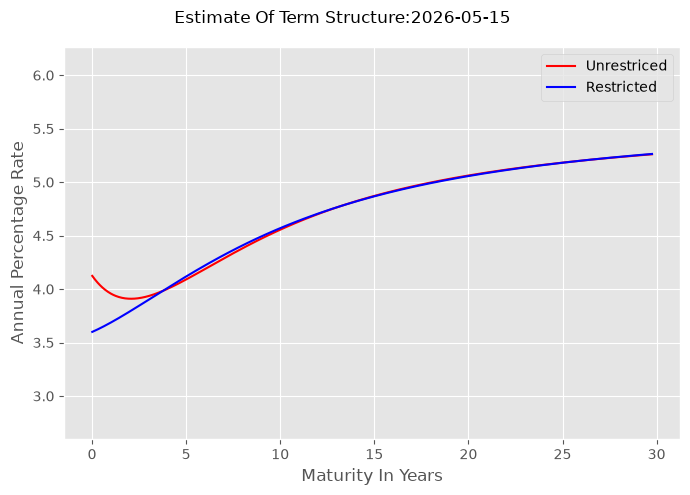

In [16]:
# graph spot rates for unrestricted and restricted estimates
# convert values to percentages
plot_data=[unrestricted_spot_rates*100,
           restricted_spot_rates*100]
#X axis time in years
xaxis=maturity_years

# labels
series=['Unrestriced',
        'Restricted']
ylabel='Annual Percentage Rate'
xlabel='Maturity In Years'
size=(7,5)
markers=['']*2
colors=['r','b']

# use nanmin and nanmax so that nan is ignored
y_lower=np.nanmin(plot_data)-1
y_upper=np.nanmax(plot_data)+1


ylim=[y_lower,y_upper]
title='Estimate Of Term Structure:'+settlement.strftime('%Y-%m-%d ')
fq.one_y_axis(xaxis,plot_data,title,series,xlabel,ylabel,markers,size,ylim,
           colors=colors)

## 🧮 Calculating Par Yields: Unrestricted and Restricted Estimates

First, we define the maturity dates for the FRED constant maturity yields and SOFR.

🔔 Maturity dates of FRED constant maturity yields (in months):
```
['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
[1, 3, 6, 12, 24, 36, 60, 84, 120, 240, 360]
```
 🔔 Maturity date of SOFR: in months $\frac{3}{31}$

The DateOffset function is used to create specific maturity dates starting from the settlement date (May 15, 2026).
```
# get maturity dates in months for SOFR and constant maturity yields
maturity_dates = np.array([3/31,1,3,6,12,24,36,60,90,180,360])
```


In [17]:
# get maturity dates in months for SOFR and constant maturity yields
maturity_dates = [3/31,1,3,6,12,24,36,60,84,120,240,360]

### 🔬 Inspecting the `calc_par_yield` Function

**The Takeaway**: This function answers a specific question: "If we issue a new bond at this maturity, what coupon rate must it pay so that its price is exactly \$100 (at par)?"

First, the function checks which version of the Nelson-Siegel model we are using. If we have exactly 4 coefficients, it runs the unrestricted model (floating freely). If we have fewer, it knows we are running the restricted model and anchors the short end of our curve to the overnight SOFR rate. If the SOFR rate is passed as argument and 4 coefficients are passed, the function deletes the slope coefficient $\beta_1$.

The arguments of the function are:

* **months_to_maturity**: If greater than the frequency of payment in months, argument must be an integer.
* **interim_estimates**: Coefficients used to calculate the spot rates of the Nelson-Siegel model.
* **sofr_rate**: The SOFR rate used to anchor the model, default value is none.
* **freq**: Number of months between payment dates, default value is 6.
* **forward_start_months**: Number of months before the issue date of the bond.

The function accounts for short frequency at the end (e.g. a bond with a maturity of ten years and two months).


🧠 Recall the par yield formula:

$$\text{Par Yield}=\frac{1-PV(T)}{\sum _{t=1}^{T}PV(t)}$$


:::{dropdown} 🔍 Click to see `calc_par_yield`
:icon: search


```python
def calc_par_yield(months_to_maturity, interim_estimates, sofr_rate=None, freq=6, forward_start_months=0):
    """
    Calculates spot or forward par yields.
    
    Args:
        months_to_maturity (int/float): Tenor in months. Must be an int if >= freq.
        interim_estimates (list): Nelson-Siegel parameters.
        sofr_rate (float, optional): Short rate for restricted model.
        freq (int, optional): Payment frequency in months. Defaults to 6.
        forward_start_months (int/float, optional): Forward start period. Defaults to 0 (spot).
    """
    # 1. Guard against negative maturities
    if months_to_maturity < 0:
        raise ValueError(f"Maturity cannot be negative. Received: {months_to_maturity}")
        
    # 2. Type check: Enforce integers ONLY for swap-market maturities (>= freq)
    if months_to_maturity >= freq and not isinstance(months_to_maturity, int):
        raise TypeError(
            f"months_to_maturity must be an integer when >= freq ({freq} months). "
            f"Received: {type(months_to_maturity).__name__} ({months_to_maturity})"
        )
    
    # 3. Safeguard against exactly 0 maturity (estimates the immediate curve intercept)
    months_to_maturity = max(months_to_maturity, 0.0001)
    
    # 4. Generate schedule of relative months and accrual periods (tau)
    if months_to_maturity < freq:
        # Short end: allows fractional months and single payments
        payment_months = [months_to_maturity]
        accrual_taus = [months_to_maturity / 12.0]
    else:
        # Long end: integer scheduling and sloppy stub handling
        full_periods = int(months_to_maturity // freq)
        payment_months = list(range(freq, (full_periods * freq) + 1, freq))
        accrual_taus = [freq / 12.0] * full_periods
        
        stub_months = months_to_maturity % freq
        if stub_months > 0:
            payment_months.append(months_to_maturity)
            accrual_taus.append(stub_months / 12.0)
            
    df = pd.DataFrame({
        'relative_months': payment_months,
        'tau': accrual_taus
    })
    
    # 5. Calculate Absolute Time (T) from TODAY (t=0)
    df['T_absolute'] = (df['relative_months'] + forward_start_months) / 12.0
    
    # 6. Get Spot Rates via your Nelson-Siegel function
    # if sofr_rate present check coeff
    if sofr_rate is not None and len(interim_estimates)>3:
      interim_estimates=list(interim_estimates)
      interim_estimates.pop(1)
    spot_rates, _ = fq.ns_spot_rates(
        interim_estimates=interim_estimates,
        mat_years=df['T_absolute'].values,
        sofr_rate=sofr_rate
    )
    df['spot_rate'] = spot_rates
    
    # 7. Calculate Discount Factors back to today (t=0)
    df['DF'] = np.exp(-df['spot_rate'] * df['T_absolute'])
    
    # 8. Handle Forward Start Adjustment
    if forward_start_months > 0:
        T_start = forward_start_months / 12.0
        start_spot, _ = fq.ns_spot_rates(interim_estimates, np.array([T_start]), sofr_rate)
        DF_start = np.exp(-start_spot[0] * T_start)
    else:
        DF_start = 1.0
        
    # 9. Calculate Par Yield
    DF_N = df['DF'].iloc[-1]
    PV01 = (df['tau'] * df['DF']).sum()
    
    par_yield = (DF_start - DF_N) / PV01
    
    return par_yield
```
:::


### 📊 Estimating Par Yields with Unrestricted and Restricted Estimates

* **The unrestricted estimates** are stored in `unrestricted.x`.
* **The restricted estimates** are stored in `restricted.x`.
* **The SOFR rate** is passed to the function for both models. The `calc_par_yields` function automatically adjusts its behavior by checking the number of estimated coefficients.
* **The final results** are multiplied by 100 to convert them into percentages and rounded to two decimal places.

The function is called iteratively for each maturity date (in years).

In [18]:
 # the unrestricted and restricted estimated coefficients

# unrestricted estimates pass four coefficient estimates sofr_rate ignored

unrestricted_par_yields = [
    round(fq.calc_par_yield(maturity,unrestricted.x, freq=6)*100,2)
    for maturity in maturity_dates]

# restricted estimates pass three coefficient estiamtes sofr_rate ties down estimates
restricted_par_yields = [
    round(fq.calc_par_yield( maturity,restricted.x, freq=6, sofr_rate=sofr_rate)*100,2)
    for maturity in maturity_dates]

## 💭 We have calculated Par Yields with continuously compounded spot rates. Would discretely compounded rates affect the calculated values?

:::{seealso} AI Tip 💡
[The effect of compounding frequency on bootstrapped present value factors](https://www.google.com/search?udm=50&q=Are+bootstrapped+present+value+factors+affected+by+compounding+frequency?)
:::

:::{dropdown} 📝 Click here to reveal the answer
:color: primary

**Answer:**
Present value factors are fixed. As Shakespeare notes 'a rose is a rose by any other name'. Compounding frequency is the method of translation. The same present value factors result in the same par yields.
:::

## 🤔 Comparing our estimates to FRED

Our estimates are based on indicative prices.  The estimates of FRED are based on well curated bond prices.  We'll take FRED as the 'gold standard'. As you might expect there are noticeable differences between our estimates and FRED.  The restricted estimates are tied down to actual data, and that definitely improves the results.  The standard error of the restricted estimates is about half of the unrestricted estimates.

In [19]:
dict_par_yields={'FRED':may_15_2026.iloc[0].values,
                 'Unrestricted':unrestricted_par_yields,
                 'Restricted':restricted_par_yields}
par_yields_df=pd.DataFrame(dict_par_yields,index=may_15_2026.columns)
#par_yields_df=pd.DataFrame()
#par_yields_df['FRED']=may_15_2026.iloc[0]
display(par_yields_df)
# cacluiate the standard errorof the estimates
std_error_unrestricted=(((par_yields_df['FRED']-par_yields_df['Unrestricted'])**2).sum()/12)**0.5
std_error_restricted=(((par_yields_df['FRED']-par_yields_df['Restricted'])**2).sum()/12)**0.5
display(f'Standard Errors: Unrestricted Estimates: {std_error_unrestricted: .2f}\
  ... Restricted Estimates: {std_error_restricted: .2f}')

,FRED,Unrestricted,Restricted
SOFR,3.55,4.12,3.60
DGS1MO,3.71,4.11,3.61
DGS3MO,3.69,4.09,3.64
DGS6MO,3.77,4.06,3.67
DGS1,3.82,4.00,3.72
DGS2,4.09,3.95,3.82
DGS3,4.14,3.97,3.93
DGS5,4.26,4.12,4.14
DGS7,4.43,4.30,4.33
DGS10,4.59,4.54,4.55


'Standard Errors: Unrestricted Estimates:  0.27  ... Restricted Estimates:  0.13'

## 🐴 + 🐰 Stew: The Tale of Two Datasets (FRED vs. FEDInvest)

Paraphrasing the late Merton Miller, quantitative modeling is often a recipe for horse and rabbit stew. If you mix one horse (the data) and one rabbit (the estimation technique), the flavor of the stew is mostly dictated by the horse.

If we start with a noisy, indicative dataset like FEDInvest, our estimates will miss the mark. The restricted estimates—the better rabbit—improved our aim by anchoring our estimates to real-world data reported by FRED. Nevertheless, notable misses remain.

When it comes to estimation, data matters. The bond data the Federal Reserve uses to calculate constant maturity yields is highly curated. The FEDInvest data is indicative.

The better foundation:

* 🐴: Choosing a deeply informed, constant-maturity dataset (FRED).
* 🐰: Applying a constrained Nelson-Siegel model to ensure our short-term rates reflect reality.

The next notebook reverses our analysis. We start with a strong horse (FRED constant maturity yields) and use the well-seasoned rabbit (Nelson and Siegel estimates anchored to SOFR) to estimate the term structure. The term structure isn't just a theoretical line on a graph—it is the financial DNA of many financial products.

Our FRED-based estimates are used to manually extract forward rates and swap rates based on par yields. You will see firsthand why getting the data and the constraints right at the beginning is absolutely critical: a single basis point of error in the spot curve creates a ripple effect that misprices every forward and swap rate derived from it.